# Exploratory Data Analysis (EDA)

## 1. Import

In [1]:
import pandas as pd
import re
import sqlglot
from sqlglot import exp
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from transformers import RobertaTokenizer
import matplotlib.pyplot as plt

C:\Users\Runyu Han\AppData\Roaming\Python\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data read and cleaning
The EDA of schema rely on SQL parse.
SQL parse can structure the string into a tree structure, which can parse SQL logic rather than only string. 
Therefore, SQL parse is usage for dirty data recognization and data cleaning.

## 2.1 Duplicate data 

In [2]:
df = pd.read_csv("hf://datasets/AI4DS/sql_generator_no_cot/training_no_cot_dataset.csv")
print(f"sample size: {len(df)}")
#Drop duplicated data
dup_full = df.duplicated(subset=['prompt', 'response']).sum()
print(f"duplicated sampless: {dup_full}")
df = df.drop_duplicates(subset=['prompt', 'response'], keep='first').reset_index(drop=True)
print(f"unduplicated samples: {len(df)}")

sample size: 9399
duplicated sampless: 2
unduplicated samples: 9397


Duplicate datas provide information that already exist in dataset. It could also lead to data leakage.
Therefore, it need to be dropped.

## 2.2 Inconsistent prompt
The input of the prompt should begin with consistent words, which is "You are a data science expert" in this data set. Any inconsistent prompt would be rewritted.

In [3]:
template_start = "You are a data science expert"
non_standard = ~df['prompt'].str.startswith(template_start)
print(f"Inconsistent Prompt: {non_standard.sum()}")

Inconsistent Prompt: 0


## 2.3 Tentative parse and result check
The EDA of schema rely on SQL parse.
SQL parse can structure the string into a tree structure, which can parse SQL logic rather than only string. 
Meanwhile, the samples failing the parse generally means the schemas exist problems. Therefore, SQL parse is usage for dirty schema recognization and help to data cleaning.

In [4]:
def extract_schema_text(prompt: str) -> str:
    match = re.search(
        r"Database Schema\s*###\s*(.*?)\s*###\s*Question:",
        str(prompt), re.DOTALL | re.IGNORECASE
    )
    return match.group(1).strip() if match else ""

df['schema_text'] = df['prompt'].apply(extract_schema_text)

def try_parse_schema(schema_text: str) -> dict:
    if not schema_text.strip():
        return {'table_count': None, 'column_count': None, 'schema_parse_failed': True}
    try:
        statements = sqlglot.parse(schema_text, read="sqlite")
    except Exception:
        return {'table_count': None, 'column_count': None, 'schema_parse_failed': True}
    table_count, column_count = 0, 0
    for stmt in statements:
        if stmt is None:
            continue
        if isinstance(stmt, exp.Create) and stmt.kind == "TABLE":
            table_count += 1
            column_count += len(list(stmt.find_all(exp.ColumnDef)))
    if table_count == 0:
        return {'table_count': None, 'column_count': None, 'schema_parse_failed': True}
    return {'table_count': table_count, 'column_count': column_count, 'schema_parse_failed': False}

schema_info = df['schema_text'].apply(try_parse_schema).apply(pd.Series)
df = pd.concat([df, schema_info], axis=1)

n_failed_first_pass = df['schema_parse_failed'].sum()
print(f"Failed parse: {n_failed_first_pass}")

'CREATE TABLE voice-actors
(
	character TEXT primary key,
	"voice-actor" TEXT, -- examples: `Alan Tud' contains unsupported syntax. Falling back to parsing as a 'Command'.
'CREATE TABLE voice-actors
(
	character TEXT primary key,
	"voice-actor" TEXT, -- description: The na' contains unsupported syntax. Falling back to parsing as a 'Command'.
'CREATE TABLE voice-actors
(
	character TEXT primary key,
	"voice-actor" TEXT, -- examples: `Alan Tud' contains unsupported syntax. Falling back to parsing as a 'Command'.
'CREATE TABLE historical-terms
(
	bioguide TEXT primary key,
	end TEXT, -- examples: `1791-03-03`
	pa' contains unsupported syntax. Falling back to parsing as a 'Command'.
'CREATE TABLE social-media
(
	bioguide TEXT primary key,
	youtube TEXT, -- examples: `MaxineWaters`| ' contains unsupported syntax. Falling back to parsing as a 'Command'.
'CREATE TABLE historical-terms
(
	bioguide TEXT primary key,
	start TEXT, -- examples: `2005-12-07`| ' contains unsupported syntax. Falling 

Failed parse: 359


### 2.3.1 Failed parse reason check
By observing the failed parse dataset, it can be found that some failed parse is because of the empty schema. And other is because of some repairable reasons such as the format problem.

In [5]:
failed_df = df[df['schema_parse_failed']].copy()

is_nan_literal = (failed_df['schema_text'] == 'nan')
print(f"Empty schema: {is_nan_literal.sum()}")
print(f"Non-empty schema: {(~is_nan_literal).sum()}")

Empty schema: 28
Non-empty schema: 331


In [6]:
print(failed_df.index)

Index([   4,   11,   19,   25,   94,   97,  118,  128,  138,  141,
       ...
       8915, 9068, 9190, 9212, 9214, 9289, 9325, 9338, 9381, 9392],
      dtype='int64', length=359)


### 2.3.2 Fix failed parse data.
The empty schema samples can no longer be repaired unless using responses to predict schemas. It is much costly. Since the empty schema samples are only 28, these data are dropped.
Another failed parse samples would be fixed. 

In [7]:
n_before = len(df)
df = df[df['schema_text'] != 'nan'].reset_index(drop=True)
print(f"dropped sample size: {n_before - len(df)}")

def quote_bad_identifiers(schema_text: str) -> str:
    def fix_match(m):
        prefix, name = m.group(1), m.group(2).strip()
        if name.startswith('"'):
            return m.group(0)
        return f'{prefix}"{name}"'
    schema_text = re.sub(
        r'(CREATE TABLE\s+)((?:(?!--)[^\n(])+?)(?=\s*\n?\s*\(|\s*--)',
        fix_match, schema_text
    )
    schema_text = re.sub(
        r'(references\s+)((?:(?!--)[^\n(])+?)(?=\s*\(|\s*--|\n|,|;)',
        fix_match, schema_text, flags=re.IGNORECASE
    )
    return schema_text

df['schema_text_fixed'] = df['schema_text'].apply(quote_bad_identifiers)

dropped sample size: 28


### 2.3.3 Second time parse

In [8]:
schema_info_v2 = df['schema_text_fixed'].apply(try_parse_schema).apply(pd.Series)
df = df.drop(columns=['table_count', 'column_count', 'schema_parse_failed'])
df = pd.concat([df, schema_info_v2], axis=1)

n_failed_second_pass = df['schema_parse_failed'].sum()
print(f"Falied parse(Second): {n_failed_second_pass}")

Falied parse(Second): 98


### 2.3.4 Failed parse reason check (Second)
There exist some \r that cannot be recognized, thus correcting it to space.    

In [9]:
def clean_stray_cr(schema_text: str) -> str:
    schema_text = schema_text.replace('\r\n', '\n')
    schema_text = schema_text.replace('\r', ' ')
    return schema_text

df['schema_text_fixed'] = df['schema_text_fixed'].apply(clean_stray_cr)
schema_info_v3 = df['schema_text_fixed'].apply(try_parse_schema).apply(pd.Series)
df = df.drop(columns=['table_count', 'column_count', 'schema_parse_failed'])
df = pd.concat([df, schema_info_v3], axis=1)

n_failed_third_pass = df['schema_parse_failed'].sum()
print(f"After second fixed: {n_failed_third_pass}")

After second fixed: 0


### 2.3.5 Successful parse
After the schema cleaning, currently all 9369 samples pass the parse. These 9369 samples are the clean data.

In [10]:
def extract_sql(response: str) -> str:
    match = re.search(r"```sql\s*(.*?)\s*```", str(response), re.DOTALL | re.IGNORECASE)
    return match.group(1).strip() if match else str(response).strip()

df['sql'] = df['response'].apply(extract_sql)

def sql_parseable(sql: str) -> bool:
    try:
        return sqlglot.parse_one(sql, read="sqlite") is not None
    except Exception:
        return False

sql_ok = df['sql'].apply(sql_parseable)
n_sql_failed = (~sql_ok).sum()
print(f"Failed parse: {n_sql_failed}")

Failed parse: 0


### 2.3.6 Group the schema
Grouping is based on the tables of schema.

According to the group, it can be easily found how many datas sharing same tables. 

In [11]:
def extract_table_names(schema_text: str) -> frozenset:
    tables = re.findall(r'CREATE TABLE\s+"?([\w][\w \-]*?)"?\s*\(', schema_text, re.IGNORECASE)
    return frozenset(t.strip().lower() for t in tables)

df['table_set'] = df['schema_text'].apply(extract_table_names)
df['table_set_str'] = df['table_set'].apply(lambda s: ",".join(sorted(s)))
codes, uniques = pd.factorize(df['table_set_str'])
df['db_group_id'] = codes

print(f"Group size: {len(uniques)}")

Group size: 1447


## 2.4 Response check
In this dataset, response is a row of SQL code, generally for query. It often begin with "Select (entity name) From (table name)". If a response has less then 4 words, it should be abnormal. 
Except that, if the responses have many words except SQL code, since it might disturb the model training, it is also abnormal.
Forthermore, responses have duplication phenomenon. It might because the different of questions in prompt. 

In [12]:
empty_sql = df['sql'].str.strip().str.len() < 4
print(f"Empty Response: {empty_sql.sum()}")
if empty_sql.sum() > 0:
    print(df[empty_sql][['response', 'sql']].head())

has_extra_text = df['response'].apply(lambda r: len(str(r)) - len(re.search(r'```sql\s*(.*?)\s*```', str(r), re.DOTALL).group(0)) if re.search(r'```sql\s*(.*?)\s*```', str(r), re.DOTALL) else 0)
print(f"Unexpected response: {(has_extra_text > 50).sum()}")

response_counts = df['response'].value_counts()
n_duplicated_response = (response_counts > 1).sum()
n_rows_with_dup_response = (df['response'].map(response_counts) > 1).sum()
print(f"Duplicated response: {n_duplicated_response}")

Empty Response: 0
Unexpected response: 0
Duplicated response: 265


## 2.5 Ghost tables
There might exist some tables that only exist in schema or response. It would mislead the model to predict nonexistent response.

In [13]:
def get_schema_tables(schema_text: str):
    try:
        statements = sqlglot.parse(schema_text, read="sqlite")
        tables = set()
        for stmt in statements:
            if stmt and isinstance(stmt, exp.Create) and stmt.kind == "TABLE":
                tables.add(stmt.this.this.name.lower() if hasattr(stmt.this, 'this') else str(stmt.this).lower())
        return tables
    except Exception:
        return None

def get_sql_tables(sql: str):
    try:
        stmt = sqlglot.parse_one(sql, read="sqlite")
        return set(t.name.lower() for t in stmt.find_all(exp.Table))
    except Exception:
        return None

df['schema_tables'] = df['schema_text_fixed'].apply(get_schema_tables)
df['sql_tables'] = df['sql'].apply(get_sql_tables)

def get_ghost_tables(row):
    if row['schema_tables'] is None or row['sql_tables'] is None:
        return None
    ghost = row['sql_tables'] - row['schema_tables']
    return ghost if ghost else None
 
df['ghost_tables'] = df.apply(get_ghost_tables, axis=1)
df['tables_consistent'] = df.apply(
    lambda r: None if (r['schema_tables'] is None or r['sql_tables'] is None) else (r['ghost_tables'] is None),
    axis=1
)

n_comparable = df['tables_consistent'].notna().sum()
n_mismatch = (df['tables_consistent'] == False).sum()
print(f"Matched tables: {n_comparable}")
print(f"Ghost tables: {n_mismatch}")

Matched tables: 9369
Ghost tables: 273


In [14]:
mismatched = df[df['ghost_tables'].notna()].copy()
print(mismatched.index)

Index([  68,  187,  285,  379,  422,  674,  688,  704,  815,  925,
       ...
       8682, 8899, 8962, 9028, 9060, 9146, 9227, 9228, 9303, 9304],
      dtype='int64', length=273)


After manual query, there truly exist ghost tables. 
The cleaning data require to drop these samples.

### 2.51 Additional discovery. Some ghost tables may match the duplicated responses.
According to manural query, it can be found that some duplicated responses can match the ghost table samples.
For instance, the sample 68 has same question and response with the sample 2540. However, the sample 2540 has correct schema but the sample 68 does not. They all ask for table "allergies". The sample 2540 has it, but the sample 68 has a table called "observations" instead.

In [15]:
mismatched['response_duplicate_count'] = mismatched['response'].map(response_counts)
n_ghost_and_dup = (mismatched['response_duplicate_count'] > 1).sum()

print(f"Duplicate responses matched ghost tables: {n_ghost_and_dup}")

Duplicate responses matched ghost tables: 152


This means the appearance of ghost tables might because they matchs the wrong response.

In [16]:
db_schema_map = df.drop_duplicates(subset=['db_group_id']).set_index('db_group_id')['schema_tables'].to_dict()

def find_correct_schema(sql_tables):
    candidates = [
        db_id for db_id, tables in db_schema_map.items()
        if tables is not None and sql_tables <= tables
    ]
    return candidates

mismatched['candidate_dbs'] = mismatched['sql_tables'].apply(find_correct_schema)
mismatched['n_candidates'] = mismatched['candidate_dbs'].apply(len)
print(f"Matched ghost tables: {(mismatched['n_candidates'] > 0).sum()}")
print(f"Unmatched ghost tables: {(mismatched['n_candidates'] == 0).sum()}")

Matched ghost tables: 152
Unmatched ghost tables: 121


According to the match, 121 ghost tables' response cannot match any schema of samples, but there are still 152 ghost tables that can match the true. These ghost tables have same questions and responses as some clean data, but wrong schema. They might be produced by wrongly data enhancement. 

## 2.6 Cleanning sample

In [17]:
df = df[df['tables_consistent'] != False].reset_index(drop=True)
print(f"Dropped sample size: {n_mismatch}")
print(f"Clean sample size: {len(df)}")

Dropped sample size: 273
Clean sample size: 9096


# 3 Tokenizer
Natural language require a tokenizer to transform the string information into token ID, and tokens into input vectors via embedding. 
The Length of the tokens is a main factor to decide the dimension of vectors.
In this part, RobertaTokenizer would be used to find the statistics and distribution of the data set.

In [18]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("Salesforce/codet5-small")
assert tokenizer.vocab_size > 1000, (
    f"vocab_size only {tokenizer.vocab_size}")
print(f"Vocab_size: {tokenizer.vocab_size}")

df['prompt_tokens'] = df['prompt'].apply(lambda x: len(tokenizer.encode(str(x))))
df['response_tokens'] = df['response'].apply(lambda x: len(tokenizer.encode(str(x))))
df['total_tokens'] = df['prompt_tokens'] + df['response_tokens']

print("Prompt Tokens")
print(df['prompt_tokens'].describe())
print(f"99% quantile: {df['prompt_tokens'].quantile(0.99):.0f}")

print("Response Tokens")
print(df['response_tokens'].describe())
print(f"99% quantile: {df['response_tokens'].quantile(0.99):.0f}")

print("Total Tokens")
print(df['total_tokens'].describe())
print(f"99% quantile: {df['total_tokens'].quantile(0.99):.0f}")

Token indices sequence length is longer than the specified maximum sequence length for this model (559 > 512). Running this sequence through the model will result in indexing errors


Vocab_size: 32100
Prompt Tokens
count    9096.000000
mean      364.834982
std        91.553963
min       183.000000
25%       302.000000
50%       352.000000
75%       412.000000
max      1291.000000
Name: prompt_tokens, dtype: float64
99% quantile: 661
Response Tokens
count    9096.000000
mean       69.802001
std        29.138985
min        14.000000
25%        52.000000
50%        68.000000
75%        86.000000
max       300.000000
Name: response_tokens, dtype: float64
99% quantile: 157
Total Tokens
count    9096.000000
mean      434.636983
std       113.050107
min       201.000000
25%       357.000000
50%       422.000000
75%       497.000000
max      1420.000000
Name: total_tokens, dtype: float64
99% quantile: 782


The mean tokens are 354.83 of prompt and 69.80 of response. The mins are 183 of prompt and 14 of response. These shows the tokenizer successfully works. 
The maxs of tokens are 1291 of prompt and 300 of response, but the 99% quantiles are 661 and 157, which is only half of the max. These shows the extra large tokens size are very rare.
Half prompts have less than 352 tokens. 75% of them have less than 412 tokens.


## 3.1 Over length tokens 
RobertaTokenizer has 512 token length limite as default. The sequences exceed this length would be cut to 512 tokens. 
Prompt over 512 tokens only occupy 5,94% in total.

In [19]:
prompt_over_512 = (df['prompt_tokens'] > 512).sum()
response_over_512 = (df['response_tokens'] > 512).sum()
print(f"Prompt over 512: {prompt_over_512} ({prompt_over_512/len(df):.2%})", f"Response over 512: {response_over_512} ({response_over_512/len(df):.2%})")

Prompt over 512: 540 (5.94%) Response over 512: 0 (0.00%)


Since more then 5% samples would be cut off, an adjustment to large max_length might be necessary.

## 3.2 Token distribution

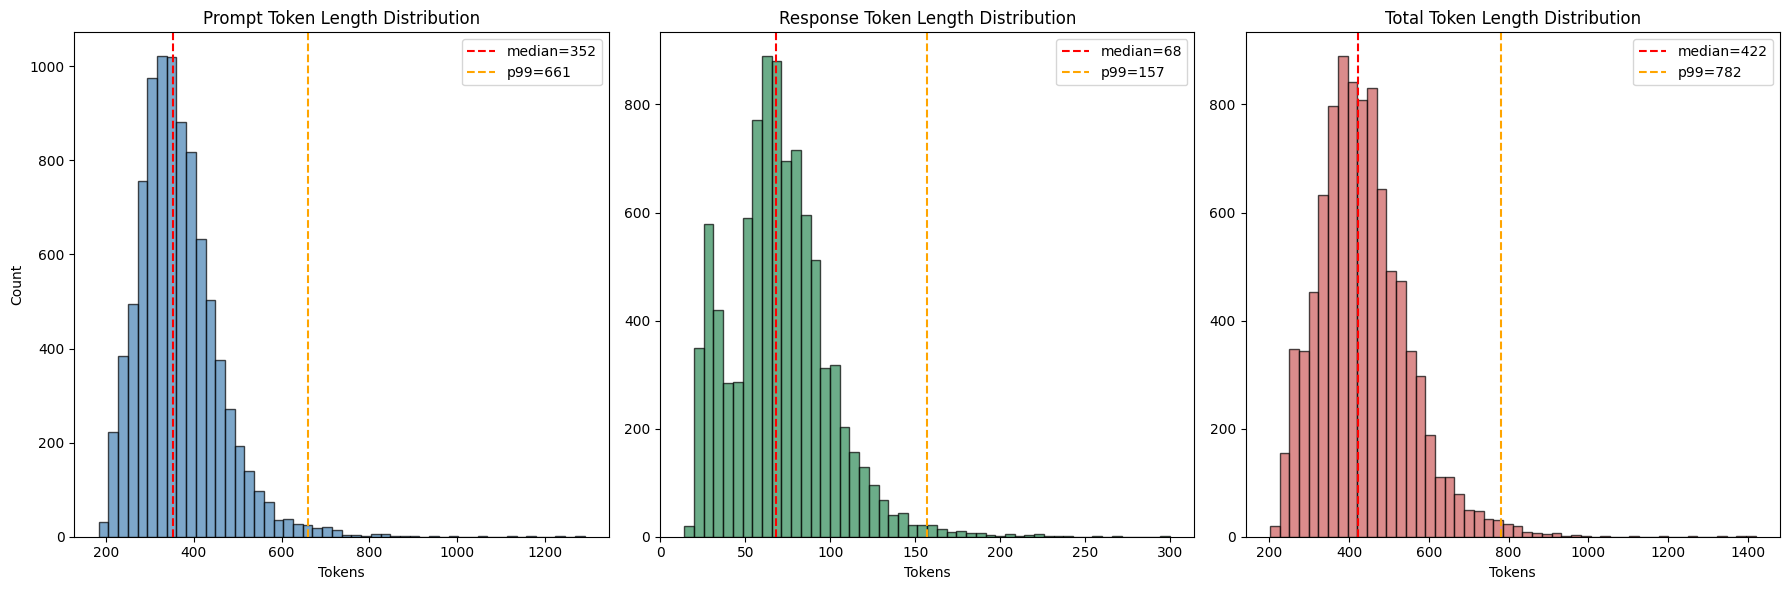

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].hist(df['prompt_tokens'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['prompt_tokens'].median(), color='red', linestyle='--', label=f"median={df['prompt_tokens'].median():.0f}")
axes[0].axvline(df['prompt_tokens'].quantile(0.99), color='orange', linestyle='--', label=f"p99={df['prompt_tokens'].quantile(0.99):.0f}")
axes[0].set_title('Prompt Token Length Distribution')
axes[0].set_xlabel('Tokens')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['response_tokens'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].axvline(df['response_tokens'].median(), color='red', linestyle='--', label=f"median={df['response_tokens'].median():.0f}")
axes[1].axvline(df['response_tokens'].quantile(0.99), color='orange', linestyle='--', label=f"p99={df['response_tokens'].quantile(0.99):.0f}")
axes[1].set_title('Response Token Length Distribution')
axes[1].set_xlabel('Tokens')
axes[1].legend()

axes[2].hist(df['total_tokens'], bins=50, color='indianred', edgecolor='black', alpha=0.7)
axes[2].axvline(df['total_tokens'].median(), color='red', linestyle='--', label=f"median={df['total_tokens'].median():.0f}")
axes[2].axvline(df['total_tokens'].quantile(0.99), color='orange', linestyle='--', label=f"p99={df['total_tokens'].quantile(0.99):.0f}")
axes[2].set_title('Total Token Length Distribution')
axes[2].set_xlabel('Tokens')
axes[2].legend()

plt.tight_layout()
fig.savefig('token_distribution.png', dpi=150)
plt.show()

Prompt's and response's token distritubions all tend to the left with long tails at the right. 
Most of the data are at the left of 99% quantile lines. 
There is only one peak of prompt token distribution at the median.

## 3.3 Correlation between prompt and response tokens

In [21]:
print("Prompt_tokens/response_tokens:", df['prompt_tokens'].corr(df['response_tokens']))
print("Table_count/response_tokens:", df['table_count'].corr(df['response_tokens']))
print("Column_count/response_tokens:", df['column_count'].corr(df['response_tokens']))

Prompt_tokens/response_tokens: 0.6651795698148176
Table_count/response_tokens: 0.6434018204068073
Column_count/response_tokens: 0.6060287583986308


Table_count/response_tokens and column_count/response_tokens are not larger than prompt_tokens/response_tokens, which means the structure complexity does not influence the SQL complexity too much.

## 4 Question Complexity
This step is to check the complexity of question by calculating the percentage occupied by negation and superlative.
Negation and superlative range would distrub natural language model's decision, especially multiple usage of negation or superlative without range constraints.

In [22]:
def extract_question(prompt):
    match = re.search(r"Question:\s*(.*?)\s*(?:Hint:|Please respond)", str(prompt), re.DOTALL | re.IGNORECASE)
    return match.group(1).strip() if match else str(prompt)

df['question'] = df['prompt'].apply(extract_question)
df['has_negation'] = df['question'].str.contains(r'\bnot\b|\bexcept\b|\bwithout\b', case=False, regex=True, na=False)
df['has_superlative'] = df['question'].str.contains(r'\bhighest\b|\blowest\b|\bmost\b|\bleast\b', case=False, regex=True, na=False)

print(f"Percentage of negation: {df['has_negation'].mean():.2%}")
print(f"Percentage of superlative: {df['has_superlative'].mean():.2%}")

Percentage of negation: 2.08%
Percentage of superlative: 16.02%


## 5 SQL complexity analysis
SQL complexity decided by its function usage.
As the samples have been cleaned and all passed the parse, complexity analysis can be directly applied without extra data cleaning.

The function extracted would utilized to the following difficulty classification.

In [23]:
def analyze_sql_complexity(sql: str) -> dict:
    try:
        stmt = sqlglot.parse_one(sql, read="sqlite")
    except Exception:
        return {"parse_failed": True}
    if stmt is None:
        return {"parse_failed": True}

    stmt_type = type(stmt).__name__
    join_count = len(list(stmt.find_all(exp.Join)))
    subquery_count = len(list(stmt.find_all(exp.Subquery)))
    agg_funcs = [type(f).__name__ for f in stmt.find_all(exp.AggFunc)]
 
    select_node = stmt.find(exp.Select)
    where_node = stmt.find(exp.Where)
    group_node = stmt.find(exp.Group)

    return {
        'parse_failed': False,
        'stmt_type': stmt_type,
        'join_count': join_count,
        'subquery_count': subquery_count,
        'agg_func_count': len(agg_funcs),
        'agg_func_types': agg_funcs,
        'has_groupby': group_node is not None,
        'has_having': stmt.find(exp.Having) is not None,
        'has_orderby': stmt.find(exp.Order) is not None,
        'has_limit': stmt.find(exp.Limit) is not None,
        'has_distinct': stmt.find(exp.Distinct) is not None,
        'is_union': stmt_type == 'Union',
        'is_intersect': stmt_type == 'Intersect',
        'is_except': stmt_type == 'Except',
        'has_where': where_node is not None,
        'has_or': stmt.find(exp.Or) is not None,
        'has_like': stmt.find(exp.Like) is not None,
        'num_select_cols': len(select_node.expressions) if select_node else 0,
        'num_where_conds': (1 + len(list(where_node.find_all(exp.And))) + len(list(where_node.find_all(exp.Or)))) if where_node else 0,
        'num_groupby_clauses': len(group_node.expressions) if group_node else 0,
    }

sql_complexity = df['sql'].apply(analyze_sql_complexity).apply(pd.Series)
df = pd.concat([df, sql_complexity], axis=1)

valid = df
print(f"Sample size: {len(valid)}")
print(valid['stmt_type'].value_counts())

Sample size: 9096
stmt_type
Select    9076
Union       20
Name: count, dtype: int64


### 5.1 SQL complexity counts
To find the complexity, the distribution of each functions usage is important.
When using join function, it means the query need cross table work. For instance, two join means the query need 3 tables.
Union function requires multiple select function.
Subquery requires a select function query outside.
These functions are more complexity since they need precondition. 

In [32]:
for col in ['has_groupby', 'has_having', 'has_orderby', 'has_limit', 'has_distinct',
            'is_union', 'is_intersect', 'is_except', 'has_where', 'has_or', 'has_like']:
    print(f"{col} percentage: {valid[col].mean():.2%}")

print(f"Join percentage: {(valid['join_count'] > 0).mean():.2%}")
print(f"subquery percentage: {(valid['subquery_count'] > 0).mean():.2%}")
print(f"agg_func percentage: {(valid['agg_func_count'] > 0).mean():.2%}")

print(f"Join number count: {(valid['join_count'].value_counts().sort_index())}")
print(f"Subquery number count: {(valid['subquery_count'].value_counts().sort_index())}")

all_agg_types = [f for types in valid['agg_func_types'] for f in types]
print(Counter(all_agg_types).most_common())

has_groupby percentage: 10.60%
has_having percentage: 1.48%
has_orderby percentage: 18.04%
has_limit percentage: 19.00%
has_distinct percentage: 11.58%
is_union percentage: 0.22%
is_intersect percentage: 0.00%
is_except percentage: 0.00%
has_where percentage: 88.01%
has_or percentage: 1.14%
has_like percentage: 6.56%
Join percentage: 76.32%
subquery percentage: 7.70%
agg_func percentage: 47.70%
Join number count: join_count
0    2154
1    5126
2    1448
3     296
4      64
5       7
6       1
Name: count, dtype: int64
Subquery number count: subquery_count
0    8396
1     624
2      56
3      14
4       4
5       1
6       1
Name: count, dtype: int64
[('Count', 3465), ('Sum', 1492), ('Avg', 310), ('Max', 242), ('Min', 91), ('GroupConcat', 3)]


### 5.2 SQL complexity distribution

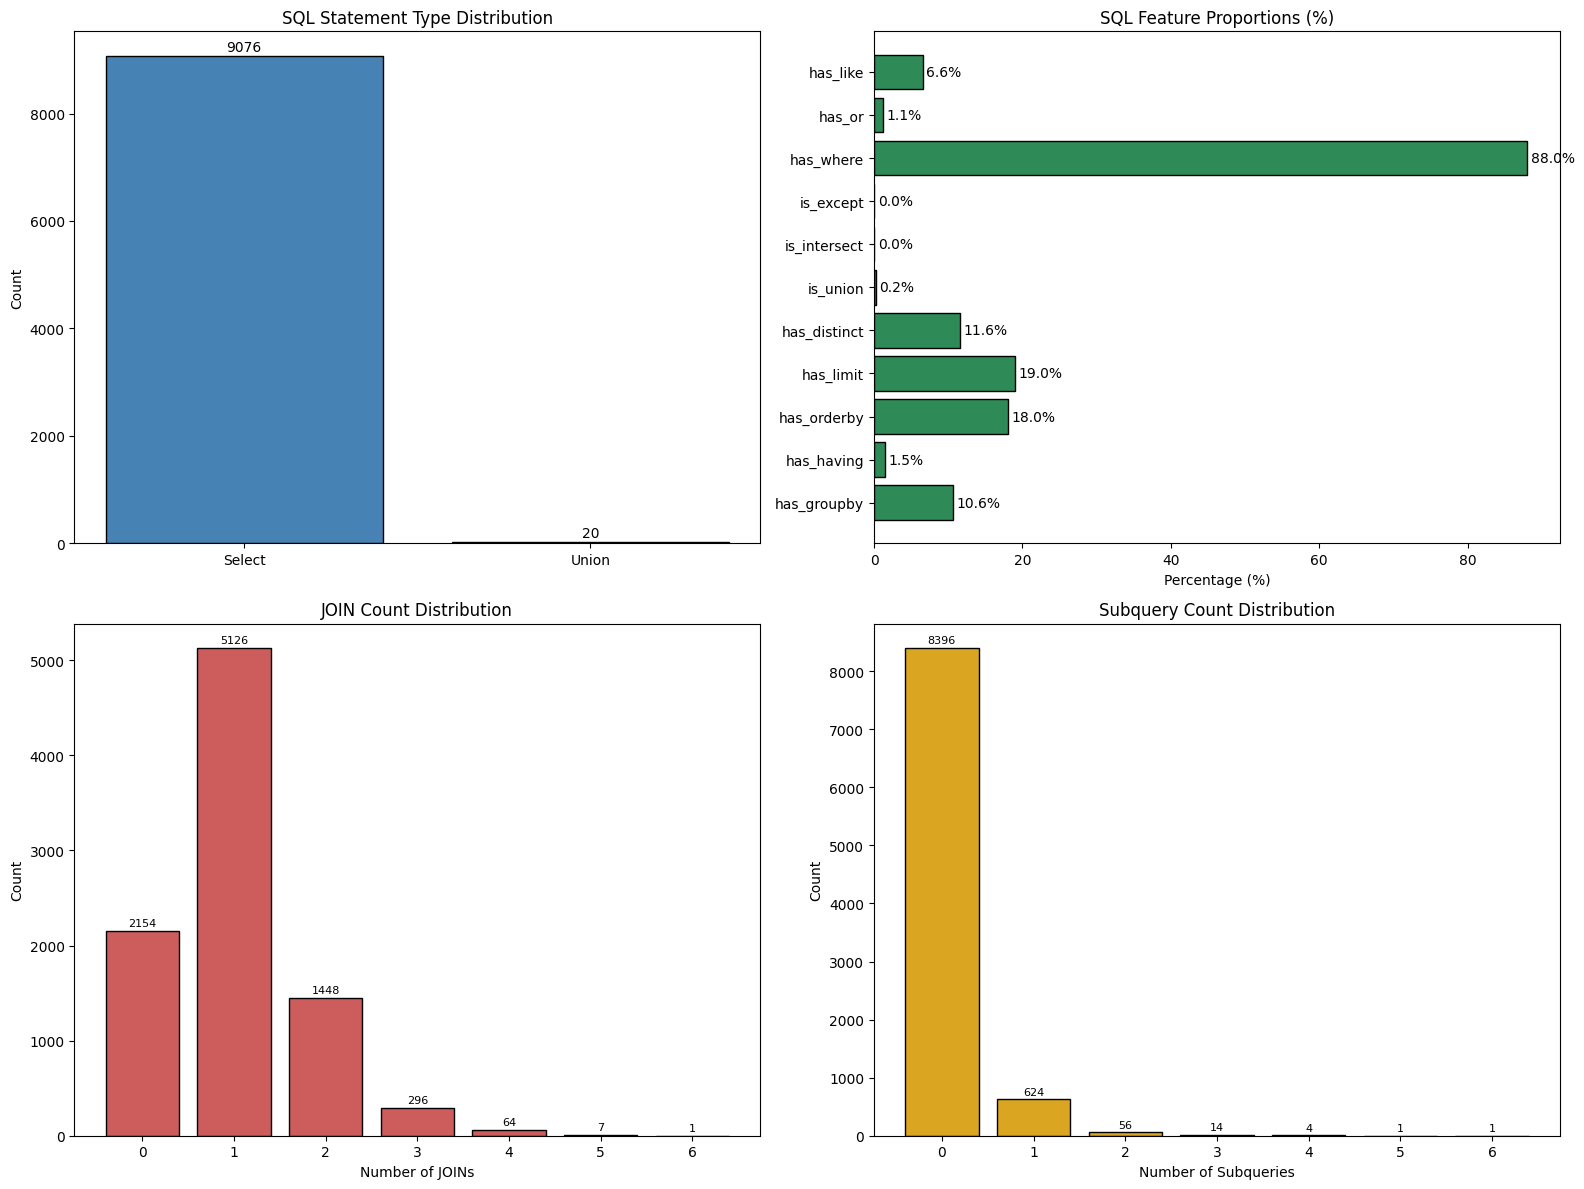

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

stmt_counts = valid['stmt_type'].value_counts()
axes[0, 0].bar(stmt_counts.index, stmt_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_title('SQL Statement Type Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(stmt_counts.values):
    axes[0, 0].text(i, v + max(stmt_counts.values) * 0.01, str(v), ha='center')

feature_cols = ['has_groupby', 'has_having', 'has_orderby', 'has_limit', 'has_distinct',
                    'is_union', 'is_intersect', 'is_except', 'has_where', 'has_or', 'has_like']
feature_pcts = [valid[col].mean() * 100 for col in feature_cols]
axes[0, 1].barh(feature_cols, feature_pcts, color='seagreen', edgecolor='black')
axes[0, 1].set_title('SQL Feature Proportions (%)')
axes[0, 1].set_xlabel('Percentage (%)')
for i, v in enumerate(feature_pcts):
    axes[0, 1].text(v + 0.5, i, f"{v:.1f}%", va='center')

join_counts = valid['join_count'].value_counts().sort_index()
axes[1, 0].bar(join_counts.index.astype(str), join_counts.values, color='indianred', edgecolor='black')
axes[1, 0].set_title('JOIN Count Distribution')
axes[1, 0].set_xlabel('Number of JOINs')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate(join_counts.values):
    axes[1, 0].text(i, v + max(join_counts.values) * 0.01, str(v), ha='center', fontsize=8)

subq_counts = valid['subquery_count'].value_counts().sort_index()
axes[1, 1].bar(subq_counts.index.astype(str), subq_counts.values, color='goldenrod', edgecolor='black')
axes[1, 1].set_title('Subquery Count Distribution')
axes[1, 1].set_xlabel('Number of Subqueries')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate(subq_counts.values):
    axes[1, 1].text(i, v + max(subq_counts.values) * 0.01, str(v), ha='center', fontsize=8)

plt.tight_layout()
fig.savefig('sql_complexity_bars.png', dpi=150)
plt.show()

## 5.3 Schema check

### 5.3.1 Duplicate schema

In [35]:
def normalize_schema_for_dedup(schema_text: str) -> str:
    blocks = re.split(r'(?=CREATE TABLE)', schema_text, flags=re.IGNORECASE)
    blocks = [b.strip() for b in blocks if b.strip()]
    blocks = [re.sub(r'\s+', ' ', b).strip().lower() for b in blocks]
    return "|||".join(sorted(blocks))

df['schema_normalized'] = df['schema_text'].apply(normalize_schema_for_dedup)
schema_dup_counts = df['schema_normalized'].value_counts()

n_unique_schemas = len(schema_dup_counts)
n_duplicated_schemas = (schema_dup_counts > 1).sum()

print(f"Different schema: {n_unique_schemas}")
print(f"Duplicate schema: {n_duplicated_schemas}")

Different schema: 8219
Duplicate schema: 546


### 5.3.2 Numbers of table and cloumns

In [ ]:
total_tables = df['table_count'].sum()
total_columns = df['column_count'].sum()

print(f"Size of tables: {total_tables}")
print(f"Size of columns: {total_columns}")

Size of tables: 19247
Size of columns: 51715


### 5.3.3 Schema complexity distribution

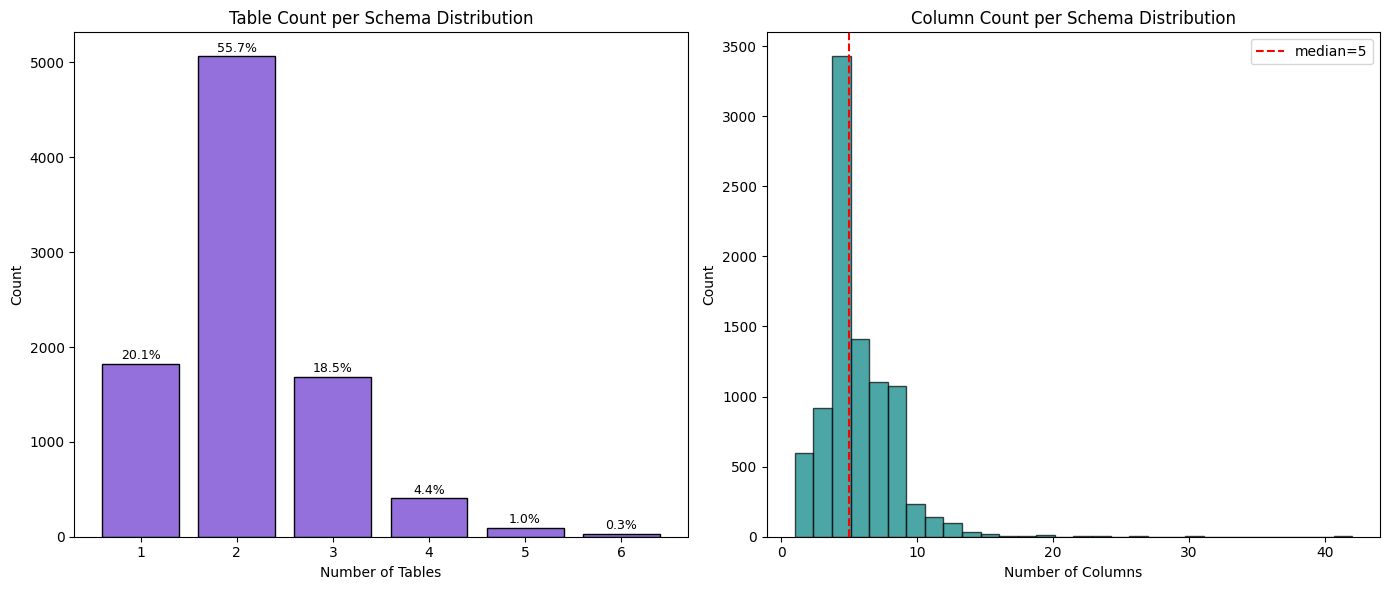

In [26]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

table_counts = df['table_count'].value_counts().sort_index()
axes2[0].bar(table_counts.index.astype(int).astype(str), table_counts.values, color='mediumpurple', edgecolor='black')
axes2[0].set_title('Table Count per Schema Distribution')
axes2[0].set_xlabel('Number of Tables')
axes2[0].set_ylabel('Count')
total = table_counts.sum()
for i, v in enumerate(table_counts.values):
    pct = v / total * 100
    axes2[0].text(i, v + max(table_counts.values) * 0.01, f"{pct:.1f}%", ha='center', fontsize=9)

axes2[1].hist(df['column_count'].dropna(), bins=30, color='teal', edgecolor='black', alpha=0.7)
axes2[1].axvline(df['column_count'].median(), color='red', linestyle='--',
                  label=f"median={df['column_count'].median():.0f}")
axes2[1].set_title('Column Count per Schema Distribution')
axes2[1].set_xlabel('Number of Columns')
axes2[1].set_ylabel('Count')
axes2[1].legend()

plt.tight_layout()
fig2.savefig('schema_complexity_bars.png', dpi=150)
plt.show()

## 6 SQL diffculity
The difficulty classification would based on spider rule.(https://github.com/taoyds/spider/blob/master/evaluation_examples/README.md)
First put functions into two components and others.

SQL components 1: WHERE, GROUP BY, ORDER BY, LIMIT, JOIN, OR, LIKE，HAVING

SQL components 2: EXCEPT, UNION, INTERSECT, NESTED

Others: number of agg > 1, number of select columns > 1, number of where conditions > 1, number of group by clauses > 1, number of group by clauses > 1 (no consider col1-col2 math equations etc.)

Then use the rules based on the components to determine the different hardness levels

In [44]:
def compute_spider_counts(row) -> dict:
    if row.get('parse_failed', True):
        return pd.Series({'comp1_count': None, 'comp2_count': None, 'others_count': None})

    comp1_count = sum([
        row['has_where'], row['has_groupby'], row['has_orderby'], row['has_limit'],
        row['join_count'] > 0, row['has_or'], row['has_like'], row['has_having']
    ])
 
    comp2_count = sum([
        row['is_except'], row['is_union'], row['is_intersect'], row['subquery_count'] > 0
    ])

    others_count = sum([
        row['agg_func_count'] > 1, row['num_select_cols'] > 1,
        row['num_where_conds'] > 1, row['num_groupby_clauses'] > 1
    ])

    return pd.Series({'comp1_count': comp1_count, 'comp2_count': comp2_count, 'others_count': others_count})
df[['comp1_count', 'comp2_count', 'others_count']] = df.apply(compute_spider_counts, axis=1)

def spider_difficulty(row) -> str:
    if row.get('parse_failed', True):
        return "unparseable"
    c1, c2, o = row["comp1_count"], row["comp2_count"], row["others_count"]
    if c1 <= 1 and o == 0 and c2 == 0:
        return "easy"
    if (o <= 2 and c1 <= 1 and c2 == 0) or (c1 == 2 and o < 2 and c2 == 0):
        return "medium"
    if (o > 2 and c1 <= 2 and c2 == 0) or \
       (2 < c1 <= 3 and o <= 2 and c2 == 0) or \
       (c1 <= 1 and o == 0 and c2 == 1):
        return "hard"
    return "extra_hard"

df['difficulty'] = df.apply(spider_difficulty, axis=1)
print(df['difficulty'].value_counts())
print(df['difficulty'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))

difficulty
medium        5177
extra_hard    2024
hard          1071
easy           824
Name: count, dtype: int64
difficulty
medium        56.92%
extra_hard    22.25%
hard          11.77%
easy           9.06%
Name: proportion, dtype: object


### 6.1 SQL difficulty distribution

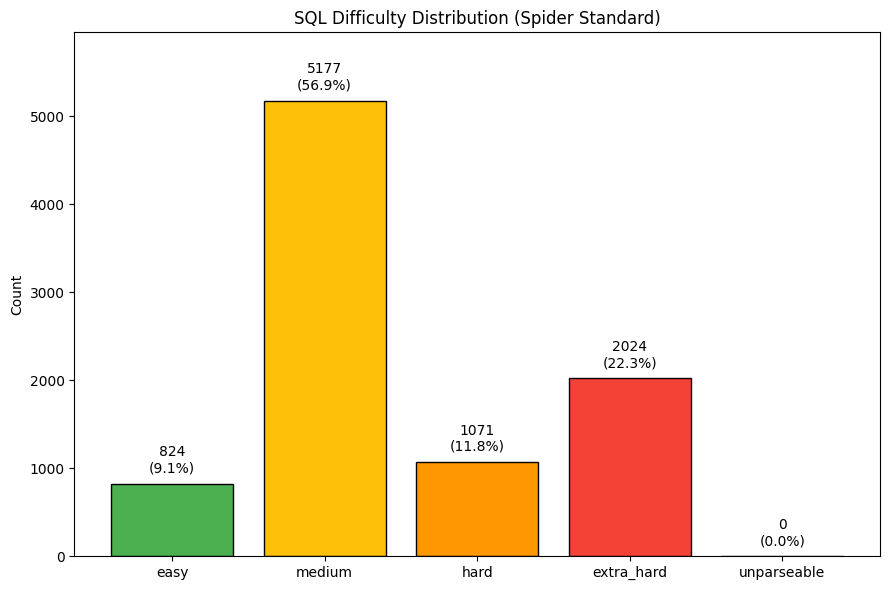

In [28]:
difficulty_counts = df['difficulty'].value_counts()
order = ['easy', 'medium', 'hard', 'extra_hard', 'unparseable']
values = [difficulty_counts.get(level, 0) for level in order]
total = sum(values)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336', '#9E9E9E']
bars = ax.bar(order, values, color=colors, edgecolor='black')
for bar, v in zip(bars, values):
    pct = v / total * 100 if total > 0 else 0
    ax.text(bar.get_x() + bar.get_width() / 2, v + total * 0.01,
             f"{v}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

ax.set_title('SQL Difficulty Distribution (Spider Standard)')
ax.set_ylabel('Count')
ax.set_ylim(0, max(values) * 1.15)

plt.tight_layout()
fig.savefig('difficulty_distribution.png', dpi=150)
plt.show()

## 7 Train / val / test split
Split is based on the group id, which can prevent the tables leakage to test set.

If the test set has same tables as train set, model may not know how to understand a new schema. The model would directly utilize a exist table. This is a kind of data leakage.

In [52]:
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.11, random_state=42)
train_val_idx, test_idx = next(gss_test.split(df, groups=df['db_group_id']))
train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.12, random_state=42)
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['db_group_id']))
train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"train: {len(train_df)} belong to {train_df['db_group_id'].nunique()} database")
print(f"val:   {len(val_df)} belong to {val_df['db_group_id'].nunique()} database")
print(f"test:  {len(test_df)} belong to {test_df['db_group_id'].nunique()} database")

train: 7145 belong to 1122 database
val:   981 belong to 154 database
test:  970 belong to 158 database


### 7.1 Difficulty in each set
It is important to know whether the difficulty of each dataset is also uniform.

If hard datas concentrate on the val and test set, easy datas concentrate, model would have lower performance.

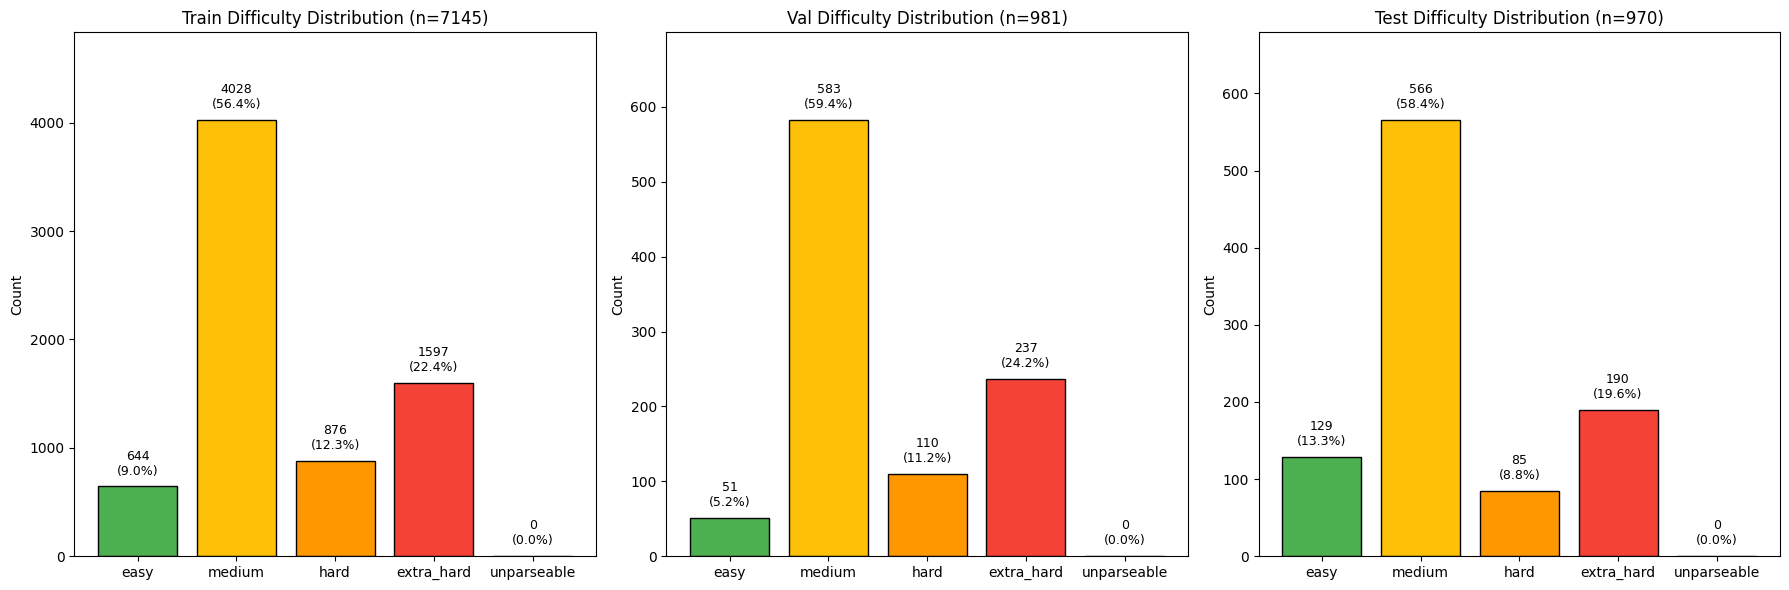

In [53]:
order = ['easy', 'medium', 'hard', 'extra_hard', 'unparseable']
colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336', '#9E9E9E']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, d) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = d['difficulty'].value_counts()
    values = [counts.get(level, 0) for level in order]
    total = sum(values)
    bars = ax.bar(order, values, color=colors, edgecolor='black')
    for bar, v in zip(bars, values):
        pct = v / total * 100 if total > 0 else 0
        ax.text(bar.get_x() + bar.get_width() / 2, v + (max(values) * 0.02 if max(values) > 0 else 0.1),
                 f"{v}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{name} Difficulty Distribution (n={total})')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(values) * 1.2 if max(values) > 0 else 1)

plt.tight_layout()
fig.savefig('difficulty_by_split.png', dpi=150)
plt.show()

The data set is large enough, thus satisfying the law of large number. The level distributions of each sets are close to the original distribution.

### 7.2 Database Check
Check the leakage via checking whether three sets have overlap databases.

In [54]:
train_dbs = set(train_df['db_group_id'])
val_dbs = set(val_df['db_group_id'])
test_dbs = set(test_df['db_group_id'])

overlap_tv = train_dbs & val_dbs
overlap_tt = train_dbs & test_dbs
overlap_vt = val_dbs & test_dbs

print(f"Train & val:  {len(overlap_tv)}")
print(f"Train & test: {len(overlap_tt)}")
print(f"Val & test:   {len(overlap_vt)}")

Train & val:  0
Train & test: 0
Val & test:   0


### 7.3 Data saved
Save only prompts and responses of each sample. Output the clean and splitted data. 

In [56]:
train_out = train_df[['prompt', 'response']]
val_out = val_df[['prompt', 'response']]
test_out = test_df[['prompt', 'response']]

train_out.to_csv("train.csv", index=False)
val_out.to_csv("val.csv", index=False)
test_out.to_csv("test.csv", index=False)

print(f"Train.csv: {len(train_out)}")
print(f"Val.csv:   {len(val_out)}")
print(f"Test.csv:  {len(test_out)}")

Train.csv: 7145
Val.csv:   981
Test.csv:  970
